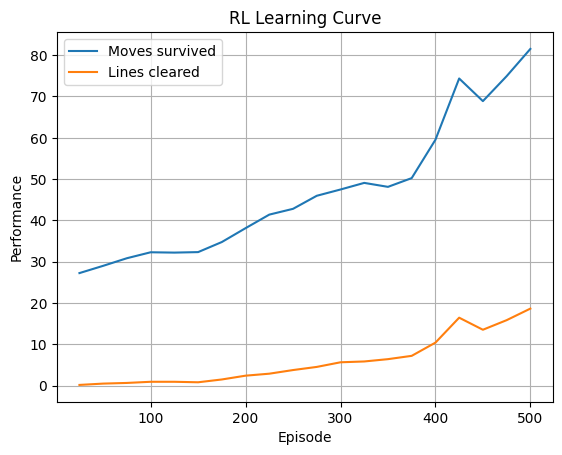

In [1]:
import matplotlib.pyplot as plt

episodes = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250,
            275, 300, 325, 350, 375, 400, 425, 450, 475, 500]

moves = [27.24, 29.00, 30.84, 32.28, 32.20, 32.32, 34.76, 38.12,
         41.40, 42.80, 45.96, 47.48, 49.08, 48.12, 50.24,
         59.52, 74.36, 68.88, 74.92, 81.52]

lines = [0.16, 0.48, 0.64, 0.92, 0.92, 0.80, 1.48, 2.40,
         2.88, 3.76, 4.52, 5.64, 5.84, 6.40, 7.20,
         10.40, 16.44, 13.52, 15.84, 18.64]

plt.plot(episodes, moves, label="Moves survived")
plt.plot(episodes, lines, label="Lines cleared")

plt.xlabel("Episode")
plt.ylabel("Performance")
plt.title("RL Learning Curve")
plt.legend()
plt.grid()

plt.show()

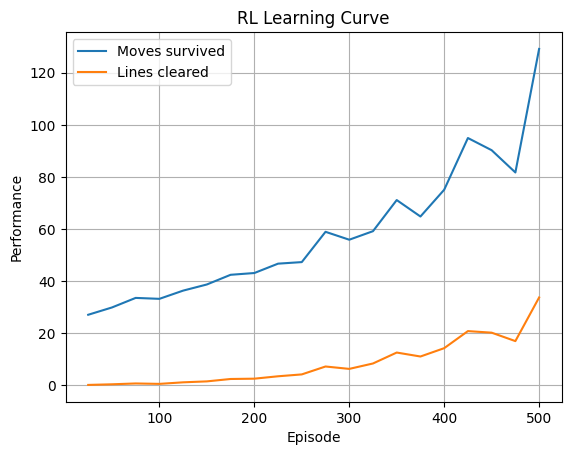

In [3]:
episodes = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250,
            275, 300, 325, 350, 375, 400, 425, 450, 475, 500]

moves = [27.00, 29.80, 33.48, 33.12, 36.28, 38.64, 42.36, 43.04,
         46.64, 47.24, 58.88, 55.84, 59.12, 71.08, 64.76,
         75.04, 94.92, 90.24, 81.68, 129.16]

lines = [0.04, 0.28, 0.60, 0.44, 1.04, 1.40, 2.32, 2.44,
         3.36, 4.08, 7.12, 6.20, 8.28, 12.48, 10.96,
         14.16, 20.72, 20.12, 16.88, 33.64]

scores = [-592.63, -611.55, -637.10, -627.55, -611.16, -585.35,
          -609.20, -626.14, -589.32, -565.82, -585.06, -572.73,
          -460.26, -465.83, -433.96, -439.72, -345.22, -307.47,
          -339.50, -278.20]

plt.plot(episodes, moves, label="Moves survived")
plt.plot(episodes, lines, label="Lines cleared")

plt.xlabel("Episode")
plt.ylabel("Performance")
plt.title("RL Learning Curve")
plt.legend()
plt.grid()

plt.show()

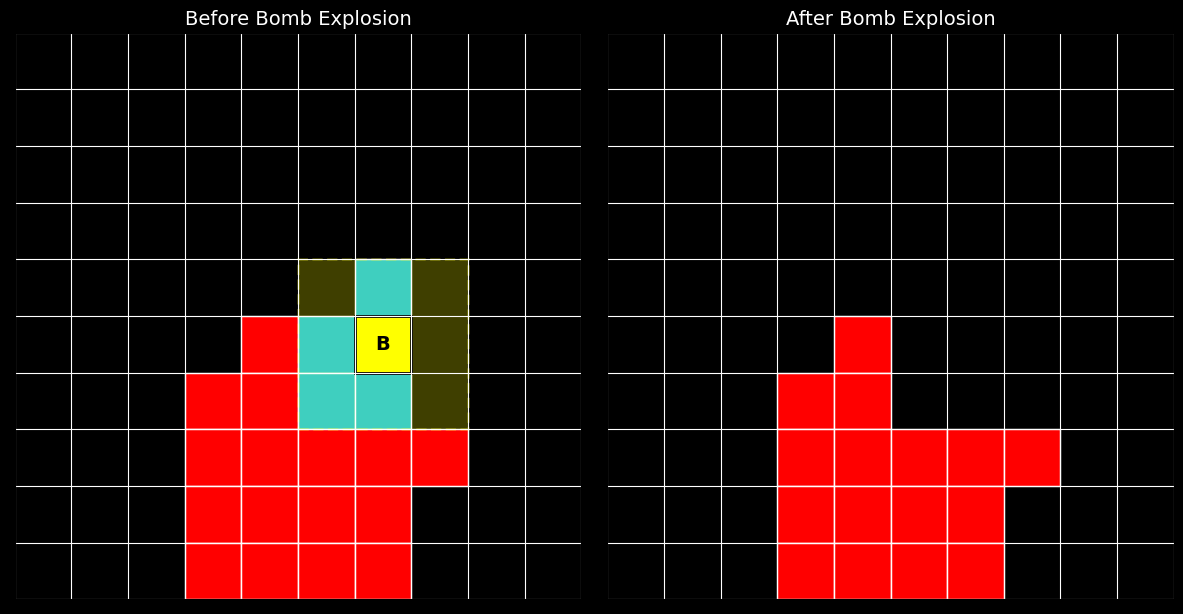

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

def draw_board(ax, grid, title,
               bomb_pos=None,
               radius=1,
               cleared_cells=None):

    rows, cols = grid.shape

    # Black background
    ax.set_facecolor("black")

    # Draw cells
    for y in range(rows):
        for x in range(cols):

            # Occupied block
            if grid[y, x] == 1:
                color = "red"

                # Highlight cells that will be cleared
                if cleared_cells and (y, x) in cleared_cells:
                    color = "deepskyblue"

                rect = Rectangle(
                    (x, rows - y - 1),
                    1,
                    1,
                    facecolor=color,
                    edgecolor="white",
                    linewidth=1
                )
                ax.add_patch(rect)

    # Draw bomb radius
    if bomb_pos is not None:
        bomb_y, bomb_x = bomb_pos

        radius_box = Rectangle(
            (bomb_x - radius,
             rows - bomb_y - radius - 1),
            2 * radius + 1,
            2 * radius + 1,
            facecolor="yellow",
            alpha=0.25,
            edgecolor="yellow",
            linewidth=2,
            linestyle="--"
        )

        ax.add_patch(radius_box)

        # Draw bomb piece
        bomb_square = Rectangle(
            (bomb_x, rows - bomb_y - 1),
            1,
            1,
            facecolor="yellow",
            edgecolor="black",
            linewidth=2
        )

        ax.add_patch(bomb_square)

        ax.text(
            bomb_x + 0.5,
            rows - bomb_y - 0.5,
            "B",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="black"
        )

    # Grid lines
    ax.set_xticks(np.arange(0, cols + 1, 1))
    ax.set_yticks(np.arange(0, rows + 1, 1))
    ax.grid(color="white", linewidth=0.8)

    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)

    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.set_title(title, color="white", fontsize=14)

    ax.set_aspect("equal")


def create_bomb_visualization():

    before = np.zeros((10, 10))

    # Example board
    before[6:10, 3:7] = 1
    before[5, 4] = 1
    before[5, 5] = 1
    before[4, 6] = 1
    before[7, 7] = 1

    bomb_y, bomb_x = 5, 6
    radius = 1

    # Place bomb
    before[bomb_y, bomb_x] = 2

    after = before.copy()

    cleared_cells = []

    # Explosion logic
    for y in range(bomb_y - radius,
                   bomb_y + radius + 1):
        for x in range(bomb_x - radius,
                       bomb_x + radius + 1):

            if 0 <= y < 10 and 0 <= x < 10:

                if after[y, x] == 1:
                    cleared_cells.append((y, x))

                after[y, x] = 0

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 6),
        facecolor="black"
    )

    draw_board(
        axes[0],
        before,
        "Before Bomb Explosion",
        bomb_pos=(bomb_y, bomb_x),
        radius=radius,
        cleared_cells=cleared_cells
    )

    draw_board(
        axes[1],
        after,
        "After Bomb Explosion"
    )

    plt.tight_layout()

    plt.savefig(
        "bomb_piece_visualization.png",
        dpi=300,
        facecolor="black",
        bbox_inches="tight"
    )

    plt.show()


create_bomb_visualization()